In [ ]:
from gsnn_mds.proc.proc import process_expression_data, process_mds_expression_data, load_and_process_drug_data 
from argparse import Namespace 
import os
import pandas as pd 
from gsnn_mds.data.AMLDataset import AMLDataset  
import numpy as np
import torch
from torch.utils.data import DataLoader

from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP 
from hnet.train.hnet import EnergyDistanceLoss

from sklearn.metrics import r2_score
from matplotlib import pyplot as plt 

# auto reimport 
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MDS DOMAIN ADAPTATION WITH HYPERNETWOKS 

Premise: Train a hypernet on AML samples and finetune the model on AML (PriorMDS=True). 


## Define args 

In [101]:
args = Namespace() 

args.data_root = '/home/teddy/local/data/evansmds/'
args.expr_norm = "rank_inv_normal"
args.expr_clip_quantiles = (0.02, 0.98) # Not used for rank_inv_normal
args.expr_normalizer_save_path = None
args.expr_n_top_genes = 1000
args.expr_var_threshold = 0.1 # Not used if expr_n_top_genes is not None
args.resp_norm = "zscore"

args.hidden_channels = 512
args.n_layers = 2
args.nonlin = 'elu'
args.dropout = 0.0 # not recommended for hnets 
args.norm = 'layer'

args.hnet_stochastic_channels = 8
args.hnet_width = 128
args.hnet_pz = 'normal'
args.hnet_nonlin = 'elu'
args.hnet_norm = 'layer'
args.n_samples = 64

args.batch_size = 512
args.train_epochs = 50
args.finetune_epochs = 50
args.lr = 1e-4
args.finetune_lr = 1e-3
args.weight_decay = 0.
args.device = 'cuda'




# Preprocess Data 

In [3]:
mds_expr_path = os.path.join(args.data_root, '20241219_WTS_Data_Proj805.csv') 
expression_data_path = os.path.join(args.data_root, 'aml_full_manuscript.csv')

# only use genes that are in the MDS expression data 
mds_genes = pd.read_csv(mds_expr_path, sep='\t').gene_id.unique().tolist()
print('# MDS gene candidates: ', len(mds_genes))


aml_expr, normalizer = process_expression_data(
    expression_data_path, mds_genes, args.expr_norm,
    quantile_clip=tuple(args.expr_clip_quantiles),
    normalizer_save_path=args.expr_normalizer_save_path,
    n_top_genes=args.expr_n_top_genes,
    var_threshold=args.expr_var_threshold
)

# MDS gene candidates:  26364
Loading gene expression data...
Selecting variable genes...
Selected top 1000 most variable genes
Applied rank_inv_normal normalization
Processed expression data: 560 samples x 1000 genes


In [4]:
# Process MDS expression data using the same normalizer
mds_expr = process_mds_expression_data(
    mds_expr_path, normalizer
)

expr = pd.concat([aml_expr, mds_expr])

Loading MDS expression data...
Applied rank_inv_normal normalization to MDS data
Processed MDS expression data: 683 samples x 1000 genes


In [5]:
# Load and process drug response data
drug_data_path = os.path.join(args.data_root, 'beataml_probit_curve_fits_v4_distr.txt')
clinical_data_path = os.path.join(args.data_root, 'beataml_clinical_for_inputs.csv')

drug = load_and_process_drug_data(drug_data_path, clinical_data_path, args.resp_norm)

# Get drug candidates for filtering
drug_candidates = (drug.inhibitor_1.str.lower().unique().tolist() + 
                    drug.inhibitor_2.str.lower().unique().tolist())
drug_candidates = [x for x in drug_candidates if pd.notna(x)]

print('# Drug candidates: ', len(drug_candidates)) 

Loading drug response data...
Loaded 68525 drug response measurements
# Drug candidates:  349


In [6]:
drug_df = pd.DataFrame({f'DRUG__{drug_name}':np.zeros(len(expr)) for drug_name in drug_candidates})
drug_df.index = expr.index 

input_df = pd.concat([expr.astype(np.float32), drug_df.astype(np.float32)], axis=1) 
input_names = input_df.columns.tolist()  

print('# Input features: ', len(input_names))  

# Input features:  1312


In [7]:
drug_ids = drug.id.unique().tolist() 
input_ids = input_df.index.unique().tolist()  

# any drug ids not in input_ids? 
no_input_drug_ids = [x for x in drug_ids if x not in input_ids]
print('# Drug IDs not in input: ', len(no_input_drug_ids))

# remove drug ids that don't have input features 
drug = drug.loc[drug.id.isin(input_ids)]


# Drug IDs not in input:  4


In [8]:
id2x = {patient_id: torch.tensor(input_df.loc[patient_id].values, dtype=torch.float)
         for patient_id in input_df.index.tolist()}

In [90]:
# Need to create train/finetune/test splits 
# 1. Finetune on AML samples (PriorMDS=False)
# 2. Finetune on MDS samples (PriorMDS=True) ; fraction of samples 
# 3. Test on MDS samples (PriorMDS=True) ; fraction of samples 

aml_clin = pd.read_csv(os.path.join(args.data_root, 'beataml_clinical_for_inputs.csv'))

prior_mds_ids = aml_clin[lambda x: (x.priorMDS == 'y') &  
                                (x['FLT3-ITD'] == 'negative')
                        ].gdc_id.tolist()

prior_mds_ids = [x for x in prior_mds_ids if x in drug_ids] 
prior_mds_ids = [x for x in prior_mds_ids if x in input_ids] 

# 2:1 split between test/finetune  
finetune_ids = np.random.choice(prior_mds_ids, size=int(len(prior_mds_ids)*0.75), replace=False)
test_ids = [x for x in prior_mds_ids if x not in finetune_ids]
train_ids = [x for x in drug.id.unique().tolist() if x not in prior_mds_ids]

train_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(train_ids)].reset_index(drop=True), input_names)
finetune_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(finetune_ids)].reset_index(drop=True), input_names)
test_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(test_ids)].reset_index(drop=True), input_names)

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
finetune_loader = DataLoader(finetune_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)

print(f'# train samples: {len(train_dataset)} [# patients: {len(train_ids)}]')
print(f'# finetune samples: {len(finetune_dataset)} [# patients: {len(finetune_ids)}]')
print(f'# test samples: {len(test_dataset)} [# patients: {len(test_ids)}]')


# train samples: 62458 [# patients: 396]
# finetune samples: 4249 [# patients: 26]
# test samples: 1395 [# patients: 9]


# Initialize Model 

In [92]:
mlp = MLP(in_channels = len(input_names), 
          out_channels = 1, 
          hidden_channels = args.hidden_channels, 
          layers = args.n_layers, 
          nonlin = args.nonlin,
          dropout = args.dropout, 
          norm = args.norm)


model = HyperNet(
    model = mlp,
    stochastic_channels=args.hnet_stochastic_channels,
    width=args.hnet_width,
    cond_dim=0,
    nonlin=args.hnet_nonlin,
    dropout=0,
    norm=args.hnet_norm,
    bias=False,
    affine=False,
    init_dict=None,
    pz=args.hnet_pz,
    learn_pz=True,
    theta_transform=None,
    nvp_kwargs={'hidden_dim': 64, 'num_layers': 8, 'nonlin': 'elu', 'mask_type': 'alternating'}) 


# FREEZE NVP 
for param in model.normalizing_flow.parameters():
    param.requires_grad = False 
    

print(f'# of mlp parameters: {sum(p.numel() for p in mlp.parameters())}')
print(f'# of hnet parameters: {sum(p.numel() for p in model.parameters())}')


model = model.to(args.device)
optim = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay) 
crit = EnergyDistanceLoss() 


# of mlp parameters: 1201153
# of hnet parameters: 155050753


# Train Model on Training Dataset

Frozen pz 

In [93]:
def predict(model, loader, samples=32):
    model.eval() 
    with torch.no_grad():
        yhats = []
        ys = []
        for batch_idx, (x, y) in enumerate(loader):
            x = x.to(args.device)
            y = y.to(args.device)

            yhat = model(x, samples=samples).squeeze(-1)
            yhats.append(yhat.detach().cpu().numpy())
            ys.append(y.detach().cpu().numpy())
            
        return np.concatenate(yhats, axis=1), np.concatenate(ys, axis=0)



In [94]:
def eval_model(model, loader):
    model.eval() 
    with torch.no_grad():

        history = {'loss':[], 'r2':[]}
        for batch_idx, (x, y) in enumerate(loader):
            x = x.to(args.device)
            y = y.to(args.device)

            yhat = model(x, samples=args.n_samples)
            loss = crit(yhat, y.view(-1, 1))
            history['loss'].append(loss.item())
            history['r2'].append(r2_score(y.view(-1, 1).detach().cpu().numpy(), yhat.mean(0).detach().cpu().numpy()))

        return {'loss':np.mean(history['loss']), 'r2':np.mean(history['r2'])}


In [95]:
history = {'train': {'loss':[], 'r2':[]}, 'test': {'loss':[], 'r2':[]}}
for epoch in range(args.train_epochs):

    model.train() 

    losses, r2s = [], []
    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(args.device)
        y = y.to(args.device)

        optim.zero_grad() 
        yhat = model(x, samples=args.n_samples)
        loss = crit(yhat, y.view(-1, 1))
        loss.backward() 
        optim.step() 

        losses.append(loss.item())
        r2s.append(r2_score(y.view(-1, 1).detach().cpu().numpy(), yhat.mean(0).detach().cpu().numpy()))
        print(f'[{batch_idx}/{len(train_loader)} >> {loss.item():.4f}]', end='\r')

    test_metrics = eval_model(model, test_loader) 

    history['train']['loss'].append(np.mean(losses))
    history['train']['r2'].append(np.mean(r2s))
    history['test']['loss'].append(test_metrics['loss'])
    history['test']['r2'].append(test_metrics['r2'])

    print(f'Epoch {epoch} | Train Loss: {history["train"]["loss"][-1]:.4f} | Train R2: {history["train"]["r2"][-1]:.4f} | Test Loss: {history["test"]["loss"][-1]:.4f} | Test R2: {history["test"]["r2"][-1]:.4f}')



Epoch 0 | Train Loss: 3.1168 | Train R2: -2.0821 | Test Loss: 2.3096 | Test R2: -0.3869
Epoch 1 | Train Loss: 2.1051 | Train R2: -0.5367 | Test Loss: 1.7051 | Test R2: -0.1005
Epoch 2 | Train Loss: 1.7344 | Train R2: -0.3659 | Test Loss: 1.8210 | Test R2: -0.8190
Epoch 3 | Train Loss: 1.7389 | Train R2: -0.6004 | Test Loss: 1.6301 | Test R2: -0.8063
Epoch 4 | Train Loss: 1.3948 | Train R2: -0.1505 | Test Loss: 1.3142 | Test R2: -0.2442
Epoch 5 | Train Loss: 1.3296 | Train R2: -0.1379 | Test Loss: 1.2443 | Test R2: -0.0310
Epoch 6 | Train Loss: 1.2144 | Train R2: -0.0211 | Test Loss: 1.1650 | Test R2: 0.0069
Epoch 7 | Train Loss: 1.1539 | Train R2: 0.0401 | Test Loss: 1.1193 | Test R2: -0.0107
Epoch 8 | Train Loss: 1.1253 | Train R2: 0.0576 | Test Loss: 1.1063 | Test R2: 0.0160
Epoch 9 | Train Loss: 1.1164 | Train R2: 0.0731 | Test Loss: 1.2246 | Test R2: -0.1309
Epoch 10 | Train Loss: 1.1716 | Train R2: 0.0337 | Test Loss: 1.1637 | Test R2: 0.0280
Epoch 11 | Train Loss: 1.1434 | Train 

# Finetune the model using target domain 

Learn pz to select the thetas that are applicable to the target domain 

In [102]:
trained_state_dict = {k:v.cpu().clone() for k,v in model.state_dict().items()}

# unfreeze nvp to learn pz 
for param in model.normalizing_flow.parameters():
    param.requires_grad = True 

#  freeze hypernet 
for param in model.f_phi.parameters():
    param.requires_grad = False 

# reinitialize optim 
optim = torch.optim.Adam(model.normalizing_flow.parameters(), lr=args.finetune_lr, weight_decay=args.weight_decay) 

In [103]:
history2 = {'train': {'loss':[], 'r2':[]}, 'test': {'loss':[], 'r2':[]}}
for epoch in range(args.finetune_epochs):

    model.train() 

    losses, r2s = [], []
    for batch_idx, (x, y) in enumerate(finetune_loader):
        x = x.to(args.device)
        y = y.to(args.device)

        optim.zero_grad() 
        yhat = model(x, samples=args.n_samples)
        loss = crit(yhat, y.view(-1, 1))
        loss.backward() 
        optim.step() 

        losses.append(loss.item())
        r2s.append(r2_score(y.view(-1, 1).detach().cpu().numpy(), yhat.mean(0).detach().cpu().numpy()))
        print(f'[{batch_idx}/{len(train_loader)} >> {loss.item():.4f}]', end='\r')

    test_metrics = eval_model(model, test_loader) 

    history2['train']['loss'].append(np.mean(losses))
    history2['train']['r2'].append(np.mean(r2s))
    history2['test']['loss'].append(test_metrics['loss'])
    history2['test']['r2'].append(test_metrics['r2'])

    print(f'Epoch {epoch} | Train Loss: {history2["train"]["loss"][-1]:.4f} | Train R2: {history2["train"]["r2"][-1]:.4f} | Test Loss: {history2["test"]["loss"][-1]:.4f} | Test R2: {history2["test"]["r2"][-1]:.4f}')


finetuned_state_dict = {k:v.cpu().clone() for k,v in model.state_dict().items()}

Epoch 0 | Train Loss: 0.8810 | Train R2: 0.3489 | Test Loss: 0.7272 | Test R2: 0.5398
Epoch 1 | Train Loss: 0.8680 | Train R2: 0.3423 | Test Loss: 0.7210 | Test R2: 0.5458
Epoch 2 | Train Loss: 0.8632 | Train R2: 0.3837 | Test Loss: 0.7174 | Test R2: 0.5521
Epoch 3 | Train Loss: 0.8451 | Train R2: 0.3878 | Test Loss: 0.7330 | Test R2: 0.5354
Epoch 4 | Train Loss: 0.8576 | Train R2: 0.3743 | Test Loss: 0.7207 | Test R2: 0.5382
Epoch 5 | Train Loss: 0.8410 | Train R2: 0.4045 | Test Loss: 0.7317 | Test R2: 0.5330
Epoch 6 | Train Loss: 0.8601 | Train R2: 0.3606 | Test Loss: 0.7318 | Test R2: 0.5257
Epoch 7 | Train Loss: 0.8389 | Train R2: 0.3976 | Test Loss: 0.7301 | Test R2: 0.5635
Epoch 8 | Train Loss: 0.8471 | Train R2: 0.3849 | Test Loss: 0.7371 | Test R2: 0.5109
Epoch 9 | Train Loss: 0.8405 | Train R2: 0.3816 | Test Loss: 0.7302 | Test R2: 0.5272
Epoch 10 | Train Loss: 0.8397 | Train R2: 0.3865 | Test Loss: 0.7262 | Test R2: 0.5258
Epoch 11 | Train Loss: 0.8657 | Train R2: 0.3583 | Te

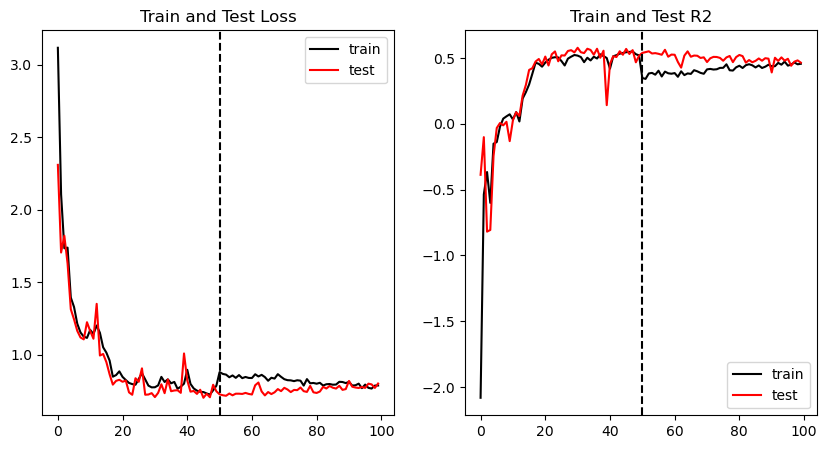

In [104]:
fig,axes = plt.subplots(1,2, figsize=(10,5))

axes[0].plot(history['train']['loss'] + history2['train']['loss'], 'k-', label='train')
axes[0].plot(history['test']['loss'] + history2['test']['loss'], 'r-', label='test')
axes[0].legend()
axes[0].set_title('Train and Test Loss')
axes[0].axvline(x=len(history['train']['loss']), color='k', linestyle='--', label='train->tune')

axes[1].plot(history['train']['r2'] + history2['train']['r2'], 'k-', label='train')
axes[1].plot(history['test']['r2'] + history2['test']['r2'], 'r-', label='test')
axes[1].legend()
axes[1].set_title('Train and Test R2')
axes[1].axvline(x=len(history['train']['loss']), color='k', linestyle='--', label='train->tune')

plt.show()


r: 0.7358, r2: -0.0620, mse: 0.4411
r_tuned: 0.6754, r2_tuned: -0.3335, mse_tuned: 0.5040


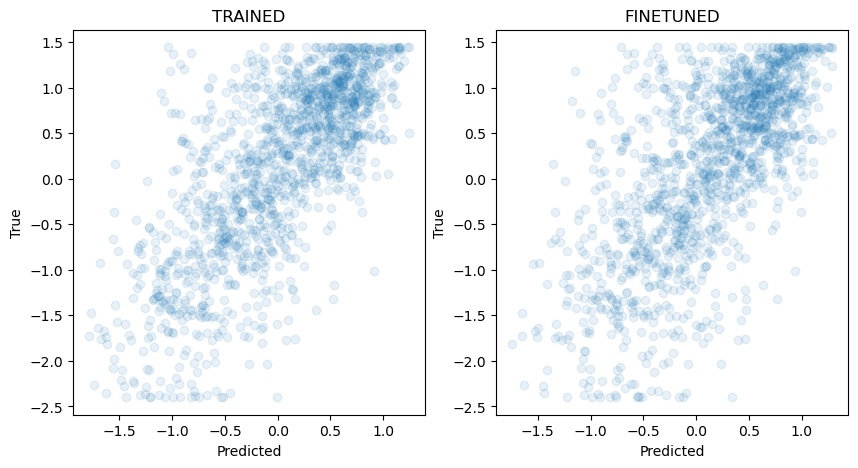

In [105]:
model.load_state_dict(trained_state_dict)
yhat, y = predict(model.to(args.device), test_loader, samples=100)

model.load_state_dict(finetuned_state_dict)
yhat2, y2 = predict(model.to(args.device), test_loader, samples=100)

r = np.corrcoef(yhat.mean(0), y)[0,1]
r2 = r2_score(yhat.mean(0), y)
mse = np.mean((yhat.mean(0) - y)**2)

r_tuned = np.corrcoef(yhat2.mean(0), y2)[0,1]
r2_tuned = r2_score(yhat2.mean(0), y2)
mse_tuned = np.mean((yhat2.mean(0) - y2)**2)

print(f'r: {r:.4f}, r2: {r2:.4f}, mse: {mse:.4f}')
print(f'r_tuned: {r_tuned:.4f}, r2_tuned: {r2_tuned:.4f}, mse_tuned: {mse_tuned:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(yhat.mean(0), y, alpha=0.1)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('TRAINED')

axes[1].scatter(yhat2.mean(0), y2, alpha=0.1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('FINETUNED')

plt.show()



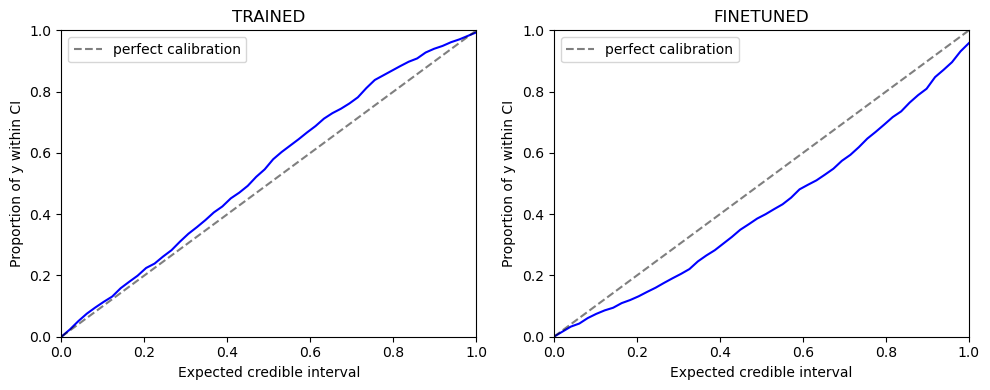

In [106]:
# CALIBRATION (RELIABILITY PLOT): proportion of y within X credible interval
# X-axis: expected credible interval (e.g. 50%, 80%, 90%), Y-axis: empirical proportion

def prop_within_ci(yhat, y, ci_levels):
    """For each CI level, compute fraction of test points where y falls in the credible interval."""
    # yhat: (n_samples, n_test), y: (n_test,)
    empirical_props = []
    for alpha in ci_levels:
        lo = (1 - alpha) / 2
        hi = (1 + alpha) / 2
        lower = np.percentile(yhat, lo * 100, axis=0)   # (n_test,)
        upper = np.percentile(yhat, hi * 100, axis=0)   # (n_test,)
        prop = np.mean((y >= lower) & (y <= upper))
        empirical_props.append(prop)
    return np.array(empirical_props)

# Expected credible intervals (50%, 60%, 70%, 80%, 90%, 95%)
expected_ci = np.linspace(0,1, 50)
empirical_prop = prop_within_ci(yhat, y, expected_ci)
empirical_prop_tuned = prop_within_ci(yhat2, y, expected_ci)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(expected_ci, empirical_prop, 'b-')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
axes[0].set_xlabel('Expected credible interval')
axes[0].set_ylabel('Proportion of y within CI')
axes[0].set_title('TRAINED')
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[1].plot(expected_ci, empirical_prop_tuned, 'b-')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
axes[1].set_xlabel('Expected credible interval')
axes[1].set_ylabel('Proportion of y within CI')
axes[1].set_title('FINETUNED')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
